In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate, integrate

rng=np.random.default_rng()

Integral= 2.213454839649102
Scipy integral= 2.215567313631897


Text(0.5, 1.0, 'Integrand')

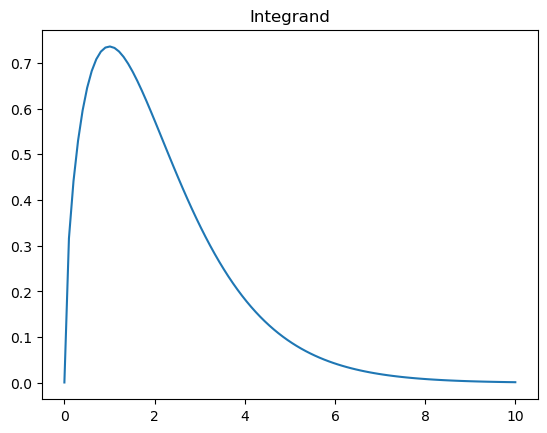

In [7]:
#7.26
x=np.linspace(1e-6,10,100)

def f(x):
    return (x**2+x)*(np.exp(-x))/np.sqrt(x)

p_x=np.exp(-x)
cdf_px=np.cumsum(p_x)/np.sum(p_x) #normalized cumulative distribution function

inv_cdf=interpolate.interp1d(cdf_px,x) #inverted and interpolated

draw_nums=rng.uniform(min(cdf_px), max(cdf_px),1000000)
draw_ys=inv_cdf(draw_nums)

ys=(draw_ys**2+draw_ys)/np.sqrt(draw_ys)

#validating
my_int = lambda x: (x**2 + x)*np.exp(-x)/np.sqrt(x)
quad_out, err = integrate.quad(my_int, 0, np.inf)

print("Integral=", np.mean(ys))
print("Scipy integral=", quad_out)

#Graphing the integrand
fig,ax=plt.subplots()
ax.plot(x,f(x))
ax.set_title("Integrand")

Integral by rejection= 7.955345749261088
Scipy integral= 7.954926521012845


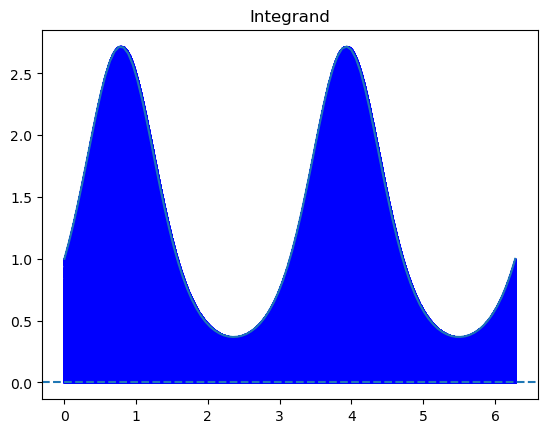

In [3]:
#7.27.1
x=np.linspace(0,2*np.pi,100)
def f(x):
    return np.exp(np.sin(2*x))

N=10000000
a=0
b=2*np.pi
ymax=3
x_i=rng.uniform(a,b,N)
y_i=rng.uniform(a,ymax,N)

#hits
is_inside=y_i<f(x_i)
is_pos=y_i>0

#rejection
area_rect=(b-a)*ymax
I_reject=area_rect*np.mean(is_inside)
print("Integral by rejection=", I_reject)

#validating
my_int = lambda x: f(x)
quad_out, err = integrate.quad(my_int, 0, 2*np.pi)
print("Scipy integral=", quad_out)

#Graphing the integrand
fig,ax=plt.subplots()
ax.plot(x,f(x))
ax.set_title("Integrand")

#Scatter
plt.scatter(x_i[is_inside*is_pos],y_i[is_inside*is_pos],c="blue",s=0.5)
plt.axhline(0,linestyle="--")

Integral by rejection 3.626046975284853
Scipy integral 3.6275987284684352


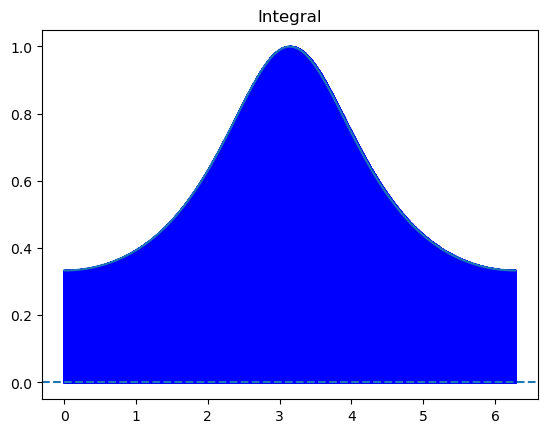

In [4]:
#7.27.2
x=np.linspace(0,2*np.pi,100)
def f(x):
    return 1/(2+np.cos(x))

N=10000000
a=0
b=2*np.pi
ymax=1
x_i=rng.uniform(a,b,N)
y_i=rng.uniform(a,ymax,N)

#hits
is_inside=y_i<f(x_i)
is_pos=y_i>0

#rejection
area_rect=(b-a)*ymax
I_reject=area_rect*np.mean(is_inside)
print("Integral by rejection",I_reject)

#validating
my_int = lambda x: f(x)
quad_out, err = integrate.quad(my_int, 0, 2*np.pi)
print("Scipy integral",quad_out)

#graphing the integrand
fig,ax=plt.subplots()
ax.plot(x,f(x))
ax.set_title("Integral")

#scatter
plt.scatter(x_i[is_inside*is_pos],y_i[is_inside*is_pos],c="blue",s=0.5)
plt.axhline(0,linestyle="--")

Integral= 1.7112160837804657
Scipy integral= 1.7112487837842973


Text(0.5, 1.0, 'Integrand')

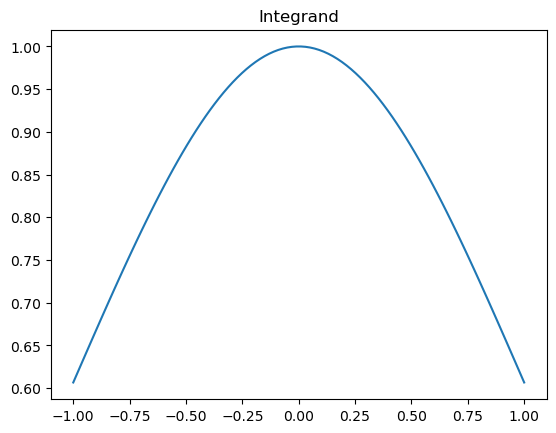

In [5]:
#7.27.3
x=np.linspace(-1,1,100)
def f(x):
    return np.exp(-x**2/2)

p=np.exp(-x**2)
p_x=p/np.trapezoid(p,x)
cdf_px=np.cumsum(p_x)/np.sum(p_x) #normalized cumulative distribution function

inv_cdf=interpolate.interp1d(cdf_px,x) #inverted and interpolated

draw_nums=rng.uniform(min(cdf_px), max(cdf_px),10000000)
draw_ys=inv_cdf(draw_nums)

ys=f(draw_ys)
p_interp = interpolate.interp1d(x,p_x,fill_value="extrapolate")

#validating
my_int = lambda x: f(x)
quad_out, err = integrate.quad(my_int, -1, 1)

print("Integral=", np.mean(ys/p_interp(draw_ys)))
print("Scipy integral=", quad_out)

fig,ax=plt.subplots()
ax.plot(x,f(x))
ax.set_title("Integrand")

Integral by rejection -0.8896749277730132
Scipy integral -0.8948314694841447


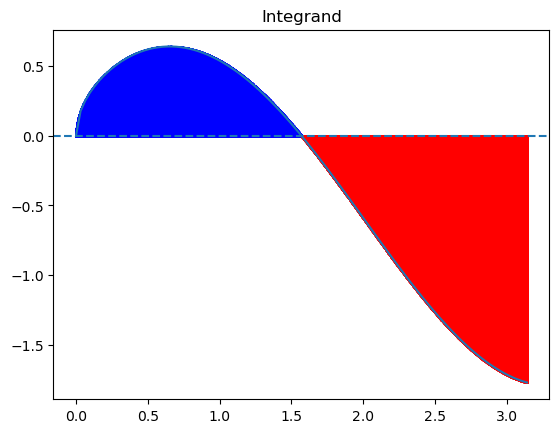

In [6]:
#7.27.3
x=np.linspace(0,np.pi,100)
def f(x):
    return np.sqrt(x)*np.cos(x)

N=10000000
a=0
b=np.pi
ymin=-1.8
ymax=0.65
x_i=rng.uniform(a,b,N)
y_i=rng.uniform(ymin,ymax,N)

#hits
is_inside=y_i<f(x_i)
is_pos=y_i>0
is_neg=y_i<0

#rejection
area_rect=(b-a)*ymax
I_reject=area_rect*(np.mean(is_inside*is_pos)-np.mean(is_inside*is_neg))
print("Integral by rejection",I_reject)

#validating
my_int = lambda x: f(x)
quad_out, err = integrate.quad(my_int, 0, np.pi)
print("Scipy integral",quad_out)

#graphing the integrand
fig,ax=plt.subplots()
ax.plot(x,f(x))
ax.set_title("Integrand")

#scatter
plt.scatter(x_i[is_inside*is_pos],y_i[is_inside*is_pos],c="blue",s=0.5)
plt.scatter(x_i[~is_inside*is_neg],y_i[~is_inside*is_neg],c="red",s=0.5)
plt.axhline(0,linestyle="--")